In [1]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
df = pd.read_csv('gemini.csv')

In [3]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
svm_model = SVC(class_weight='balanced', probability=True)

# 4. Поиск лучших параметров (C и kernel критичны для маленьких данных)
param_grid = {
    'C': [0.1, 1, 10], 
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    svm_model, 
    param_grid, 
    cv=StratifiedKFold(5), # 5-кратная проверка
    scoring='f1'           # оптимизируем под F1-меру
)

grid.fit(X_train, y_train)

# 5. Оценка результата
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba_full = best_model.predict_proba(X_test)

# 3. Извлекаем вероятность только для положительного класса (1)
y_proba = y_proba_full[:, 1]
print(f"Лучшие параметры: {grid.best_params_}")
print(classification_report(y_test, y_pred))

Лучшие параметры: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

         0.0       0.78      0.88      0.82         8
         1.0       0.89      0.80      0.84        10

    accuracy                           0.83        18
   macro avg       0.83      0.84      0.83        18
weighted avg       0.84      0.83      0.83        18



In [5]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 83.33%


Accuracy:0.833
Precision:0.889
Recall:  0.800
F1-score: 0.842

Confusion Matrix:
 [[7 1]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.88      0.82         8
         1.0       0.89      0.80      0.84        10

    accuracy                           0.83        18
   macro avg       0.83      0.84      0.83        18
weighted avg       0.84      0.83      0.83        18

F1-результаты по фолдам: [1. 1. 1. 1. 1.]
Средний F1: 1.00


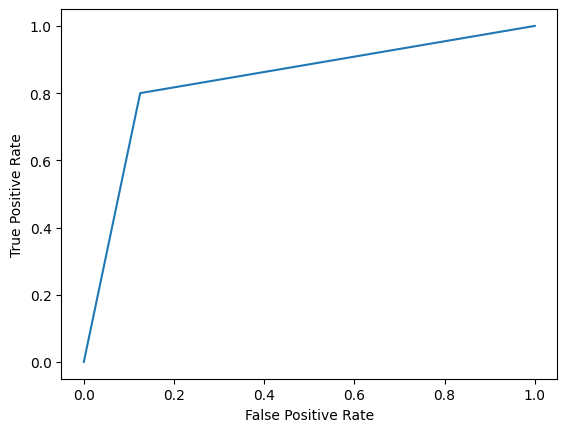

In [6]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, best_model, X_test)

In [7]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.833
Precision:0.889
Recall:  0.800
F1-score: 0.842
ROC-AUC:0.888

Confusion Matrix:
 [[7 1]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.88      0.82         8
         1.0       0.89      0.80      0.84        10

    accuracy                           0.83        18
   macro avg       0.83      0.84      0.83        18
weighted avg       0.84      0.83      0.83        18



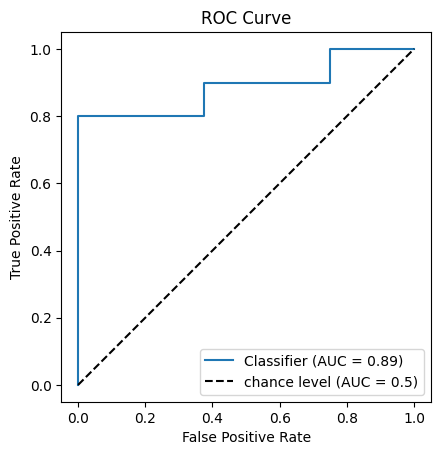

In [8]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

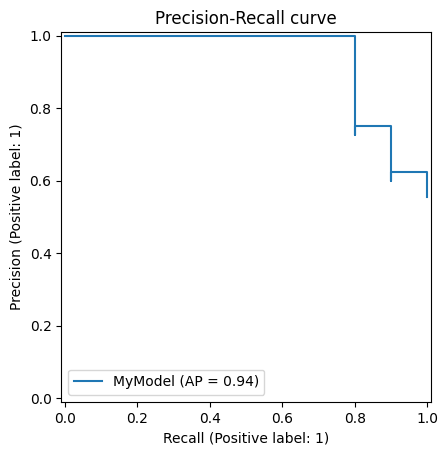

In [9]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()